In [13]:
import scanpy as sc
import pandas as pd 
st_data = sc.read_h5ad('/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/metric/HumanLymph/totalData.h5ad')
niche = sc.read_h5ad('/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Nicheformer/partialFineTune/processed.h5ad')
st_data.obs['Nicheformer_fine'] = niche.obs['pred_str'].values
data = sc.read_h5ad('/maiziezhou_lab2/yuling/SToFM/fine_tuned_ddp/test_with_predictions.h5ad')
st_data.obs['scCello_linearProbing'] = st_data.obs['Predicted']
st_data.obs['SToFM'] = data.obs['pred_original_clusters']
st_data

AnnData object with n_obs × n_vars = 39167 × 28943
    obs: 'cell_ID_mask', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_reads', 'reads_per_counts', 'n_joined', 'exact_entropy', 'theoretical_entropy', 'exact_compression', 'theoretical_compression', 'n_counts', 'annotation', 'annotation_key', 'n_section', 'original_clusters', 'batch', 'Annotated', 'Predicted', 'scGPT reference mapping', 'nicheformer', 'RCTD', 'GraphST', 'scGPT linear probing', 'scGPT fine tuning', 'CARD', 'scANVI', 'Seurat', 'SingleR', 'SpatialDWLS', 'SPOTlight', 'SpatialID', 'TACCO', 'Tangram', 'DestVI', 'scCello_finetune', 'cell2location', 'Nicheformer_fine', 'scCello_linearProbing', 'SToFM'
    uns: 'Annotated_colors', 'CARD_colors', 'GraphST_colors', 'Predicted_colors', 'RCTD_colors', 'SPOTlight_colors', 'Seurat_colors', 'SingleR_colors', 'SpatialDWLS_colors', 'SpatialID_colors', 'TACCO_colors', 'Tangram_colors', 'cell2location_colors', 'nicheformer_colors', 'scANVI_colors', 'scCello_f

# input

In [14]:
# cell type * cell id matrix containing enrichment score 
df = pd.read_csv("/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Markers/GSVA_Reactome_Human.txt", sep="\t")

# AUC

In [15]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score


methods = [
    'scGPT reference mapping', 'nicheformer', 'RCTD', 'GraphST',
    'scGPT linear probing', 'scGPT fine tuning', 'CARD', 'scANVI',
    'Seurat', 'SingleR', 'SpatialDWLS', 'SPOTlight', 'SpatialID',
    'TACCO', 'Tangram', 'DestVI', 'scCello_finetune',
    'cell2location', 'Nicheformer_fine', 'scCello_linearProbing', 'SToFM'
]


target_celltypes = ['CAF', 'Plasma_IgG', 'Fibroblasts', 'Tumor']
obs = st_data.obs.copy()
obs.index = obs.index.astype(str)

df2 = df.copy()
df2.columns = df2.columns.astype(str)  # cells
df2.index = df2.index.astype(str)      # cell types

missing_methods = [m for m in methods if m not in obs.columns]
if missing_methods:
    raise ValueError(f"These methods not in adata.obs: {missing_methods}")

missing_ct = [ct for ct in target_celltypes if ct not in df2.index]
if missing_ct:
    raise ValueError(f"These cell type not in df.index: {missing_ct}")

common_cells = obs.index.intersection(df2.columns)
if len(common_cells) == 0:
    raise ValueError("st_data.obs.index does not have intersection with df.columns")

obs_sub = obs.loc[common_cells, methods].copy()
df_sub = df2.loc[target_celltypes, common_cells].copy()

rows = []

for method in methods:
    pred = obs_sub[method].astype(str).values   

    for ct in target_celltypes:
        y = (pred == ct).astype(int)
        x = pd.to_numeric(df_sub.loc[ct], errors='coerce').values
        mask = np.isfinite(x)
        x_valid = x[mask]
        y_valid = y[mask]

        n = int(len(x_valid))
        n_pos = int(y_valid.sum())
        n_neg = int(n - n_pos)

        if n < 3 or np.unique(y_valid).size < 2 or np.unique(x_valid).size < 2:
            auc = np.nan
            note = "insufficient_variance_or_too_few_cells"
        else:
            auc = float(roc_auc_score(y_valid, x_valid))
            note = "ok"

        rows.append({
            "method": method,
            "cell_type": ct,
            "n_cells_used": n,
            "n_pred_positive": n_pos,
            "n_pred_negative": n_neg,
            "auc": auc,
            "note": note
        })

auc_df = pd.DataFrame(rows)

auc_df["method"] = pd.Categorical(auc_df["method"], categories=methods, ordered=True)
auc_df["cell_type"] = pd.Categorical(auc_df["cell_type"], categories=target_celltypes, ordered=True)
auc_df = auc_df.sort_values(["cell_type", "method"]).reset_index(drop=True)


print(auc_df.head(50))
print("Rows:", len(auc_df))


                     method    cell_type  n_cells_used  n_pred_positive  \
0   scGPT reference mapping          CAF         39167             1492   
1               nicheformer          CAF         39167              403   
2                      RCTD          CAF         39167             4774   
3                   GraphST          CAF         39167                0   
4      scGPT linear probing          CAF         39167                0   
5         scGPT fine tuning          CAF         39167             1250   
6                      CARD          CAF         39167             3953   
7                    scANVI          CAF         39167             2995   
8                    Seurat          CAF         39167             2563   
9                   SingleR          CAF         39167             2718   
10              SpatialDWLS          CAF         39167              468   
11                SPOTlight          CAF         39167             3797   
12                Spatial

# Figure 5c

/tmp/ipykernel_1548636/1845027081.py:159: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_1548636/1845027081.py:170: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You can now control the size of each plot element using matplotlib `Line2D` parameters (e.g., `linewidth`, `markersize`, etc.).

  sns.pointplot(
/tmp/ipykernel_1548636/1845027081.py:170: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(
/tmp/ipykernel_1548636/1845027081.py:159: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/tmp/ipykernel_1548636/1845027081.py:170: UserWarning: 

The `scale` parameter is deprecated and will be removed in v0.15.0. You 

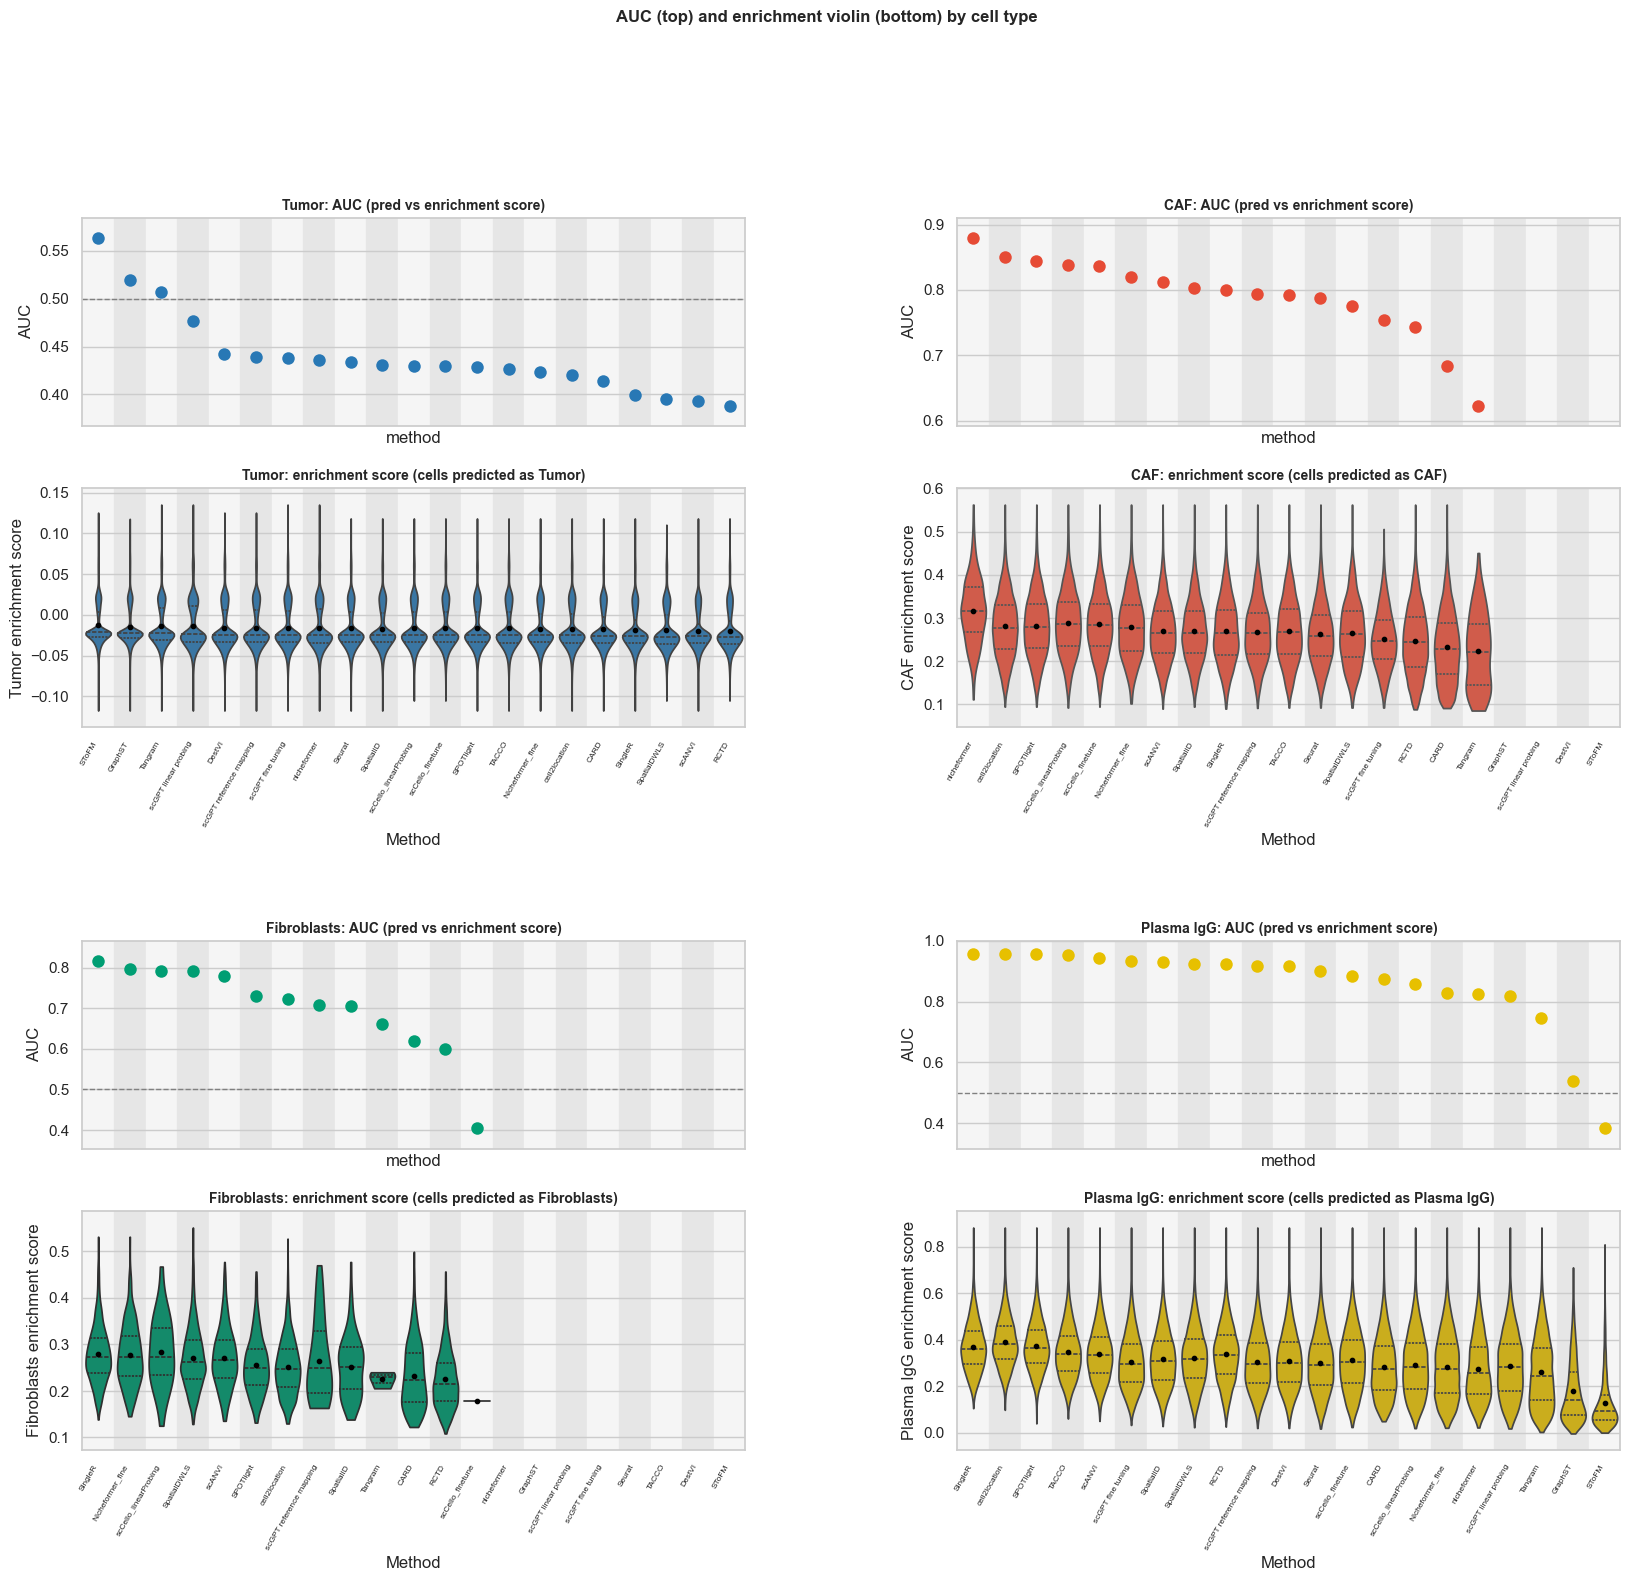

Saved: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Markers/HumanLymph/Tumor/auc_plus_violin_Figure5C_2x2_stacked.pdf
Saved: /maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Markers/HumanLymph/Tumor/auc_plus_violin_Figure5C_2x2_stacked.svg


In [19]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams["pdf.fonttype"] = 42
mpl.rcParams["ps.fonttype"] = 42
mpl.rcParams["text.usetex"] = False
mpl.rcParams["pdf.use14corefonts"] = False
mpl.rcParams["svg.fonttype"] = "none"
mpl.rcParams["font.family"] = "Arial"

if "auc" not in auc_df.columns:
    raise KeyError("auc_df should include 'auc'.")

plot_df_all = auc_df.copy()


CELL_PANELS = [
    ("Tumor", "Tumor", "#2878B5"),
    ("CAF", "CAF", "#E64B35"),
    ("Fibroblasts", "Fibroblasts", "#009E73"),
    ("Plasma IgG", "Plasma_IgG", "#E7C000"),
]

df2 = df.copy()
df2.columns = df2.columns.astype(str)
df2.index = df2.index.astype(str)
obs = st_data.obs.copy()
obs.index = obs.index.astype(str)
common_cells_all = df2.columns.intersection(obs.index)
if len(common_cells_all) == 0:
    raise ValueError("No common cells between df.columns and st_data.obs.index.")

sns.set(style="whitegrid")

n_m = max(
    12,
    int(plot_df_all.loc[plot_df_all["note"] == "ok", "method"].nunique()),
)
fig_w = max(14.0, n_m * 0.45 * 2)

fig = plt.figure(figsize=(fig_w * 1.05, 16))
outer = fig.add_gridspec(2, 2, hspace=0.42, wspace=0.32)


def _ylim_from_values(vals, pad_frac=0.08, hard_lo=0.0, hard_hi=1.0):
    vals = np.asarray(vals, dtype=float)
    vals = vals[np.isfinite(vals)]
    if vals.size == 0:
        return None
    vmin, vmax = float(vals.min()), float(vals.max())
    span = vmax - vmin
    if span <= 0:
        pad = max(abs(vmin) * 0.05, 0.02) if vmin != 0 else 0.02
    else:
        pad = span * pad_frac
    lo = vmin - pad
    hi = vmax + pad
    lo = max(hard_lo, lo)
    hi = min(hard_hi, hi)
    if hi - lo < 1e-6:
        lo, hi = max(hard_lo, vmin - 0.05), min(hard_hi, vmax + 0.05)
    return lo, hi


for idx, (disp_name, ct_key, panel_color) in enumerate(CELL_PANELS):
    r, c = divmod(idx, 2)
    inner = outer[r, c].subgridspec(2, 1, height_ratios=[1, 1.15], hspace=0.28)
    ax_top = fig.add_subplot(inner[0])
    ax_bot = fig.add_subplot(inner[1], sharex=ax_top)

    if ct_key not in df2.index:
        ax_top.text(0.5, 0.5, f"{ct_key} not in df.index", ha="center", va="center", transform=ax_top.transAxes)
        ax_bot.set_visible(False)
        continue

    sub = plot_df_all[
        (plot_df_all["note"] == "ok")
        & (plot_df_all["cell_type"].astype(str) == ct_key)
    ].copy()
    sub["auc"] = pd.to_numeric(sub["auc"], errors="coerce")
    sub = sub.dropna(subset=["auc", "method"])

    if sub.empty:
        ax_top.text(0.5, 0.5, f"No ok AUC for {disp_name}", ha="center", va="center", transform=ax_top.transAxes)
        ax_bot.text(0.5, 0.5, f"No ok AUC for {disp_name}", ha="center", va="center", transform=ax_bot.transAxes)
        continue

    method_rank = (
        sub.groupby("method", as_index=False)["auc"]
        .mean()
        .sort_values("auc", ascending=False)
    )
    final_order = method_rank["method"].tolist()

    sub_plot = sub[sub["method"].astype(str).isin(final_order)].copy()
    sub_plot["method"] = pd.Categorical(
        sub_plot["method"], categories=final_order, ordered=True
    )

    for i, _m in enumerate(final_order):
        bg = "0.96" if i % 2 == 0 else "0.90"
        ax_top.axvspan(i - 0.5, i + 0.5, color=bg, zorder=0)
        ax_bot.axvspan(i - 0.5, i + 0.5, color=bg, zorder=0)

    sns.stripplot(
        data=sub_plot,
        x="method",
        y="auc",
        order=final_order,
        color=panel_color,
        jitter=False,
        size=9,
        ax=ax_top,
        zorder=3,
    )
    auc_lim = _ylim_from_values(sub_plot["auc"].values, pad_frac=0.12, hard_lo=0.0, hard_hi=1.0)
    if auc_lim is not None:
        ax_top.set_ylim(auc_lim)
    ax_top.axhline(0.5, linestyle="--", linewidth=1, color="0.5", zorder=2)
    ax_top.set_ylabel("AUC")
    ax_top.set_title(
        f"{disp_name}: AUC (pred vs enrichment score)",
        fontsize=10,
        fontweight="bold",
    )
    ax_top.tick_params(axis="x", labelbottom=False)

    plot_rows = []
    for method in final_order:
        if method not in obs.columns:
            continue
        pred_series = obs.loc[common_cells_all, method].astype(str)
        pos_cells = pred_series.index[pred_series == ct_key]
        if len(pos_cells) == 0:
            continue
        vals = pd.to_numeric(df2.loc[ct_key, pos_cells], errors="coerce").dropna().values
        plot_rows.extend({"method": method, "enrichment_score": v} for v in vals)

    violin_df = pd.DataFrame(plot_rows)
    if violin_df.empty:
        ax_bot.text(
            0.5,
            0.5,
            "No violin data\n(pred==cell type)",
            ha="center",
            va="center",
            transform=ax_bot.transAxes,
            fontsize=9,
        )
    else:
        violin_df["method"] = pd.Categorical(
            violin_df["method"], categories=final_order, ordered=True
        )
        sns.violinplot(
            data=violin_df,
            x="method",
            y="enrichment_score",
            order=final_order,
            cut=0,
            scale="width",
            inner="quartile",
            color=panel_color,
            ax=ax_bot,
        )
        sns.pointplot(
            data=violin_df,
            x="method",
            y="enrichment_score",
            order=final_order,
            estimator=np.mean,
            errorbar=None,
            join=False,
            markers="o",
            color="black",
            scale=0.55,
            ax=ax_bot,
        )
        vlim = _ylim_from_values(
            violin_df["enrichment_score"].values,
            pad_frac=0.08,
            hard_lo=-np.inf,
            hard_hi=np.inf,
        )
        if vlim is not None:
            ax_bot.set_ylim(vlim)

    ax_bot.set_ylabel(f"{disp_name} enrichment score")
    ax_bot.set_xlabel("Method")
    ax_bot.set_title(
        f"{disp_name}: enrichment score (cells predicted as {disp_name})",
        fontsize=10,
        fontweight="bold",
    )
    tick_rot = 60
    tick_fs = 6
    ax_bot.set_xticks(np.arange(len(final_order)))
    ax_bot.set_xticklabels(final_order, rotation=tick_rot, ha="right", fontsize=tick_fs)

fig.suptitle(
    "AUC (top) and enrichment violin (bottom) by cell type",
    fontsize=12,
    fontweight="bold",
    y=1.01,
)
fig.tight_layout(h_pad=1.0, w_pad=0.6, pad=0.5, rect=[0, 0.02, 1, 0.97])

out_dir = "/maiziezhou_lab2/yuling/MouseSpinal/label_transfer/Markers/HumanLymph/Tumor"
out_pdf = f"{out_dir}/auc_plus_violin_Figure5C_2x2_stacked.pdf"
out_svg = f"{out_dir}/auc_plus_violin_Figure5C_2x2_stacked.svg"
os.makedirs(out_dir, exist_ok=True)
fig.savefig(out_pdf, bbox_inches="tight")
fig.savefig(out_svg, bbox_inches="tight")
plt.show()
print(f"Saved: {out_pdf}")
print(f"Saved: {out_svg}")
